#  Исследование результатов А/В-теста и поиск инсайтов

SollmaFin — международное мобильное приложение для онлайн-торговли финансовыми активами. Пользователи могут инвестировать деньги в акции, валюту, криптовалюту, биржевые фонды (ETF) и другие активы. Целевая аудитория приложения - начинающие инвесторы. Получить доступ к финансовым рынкам можно со смартфона либо через веб-версию. 

Приложение ориентировано на рынок Латинской Америки с акцентом на четыре страны: Мексику, Бразилию, Колумбию и Аргентину - там быстро растёт интерес к финтеху и инвестициям, а экономики очень разные. 

Появилась гипотеза о недостаточной финансовой грамотности пользователей: они не понимают, как работать с активами разной степени риска. Клиенты покупают активы с высоким риском и теряют деньги, что снижает вовлечённость.
Команда продукта решила обновить онбординг пользователей и добавить в него детальную информацию о различиях финансовых активов и связанных с ними рисках. Однако появилось опасение, что углублённый онбординг отпугнёт клиентов от пополнения депозита и более рискованных вложений. 

Чтобы разобраться, команда решила провести A/B-эксперимент. 

### А/В-эксперимент

В эксперименте участвовали новые пользователи, которые зарегистрировались в приложении со 2 по 15 июня 2025 года. 
Пользователей случайным образом разделили на две равные группы: 
- Контрольная группа проходила стандартный онбординг без обязательного обучения.
- Тестовая группа проходила обновлённый онбординг с подробной информацией об активах и связанных с ними рисках. 

После разделения активность пользователей анализировали в течение недели.

Цель эксперимента - оценить, как обновлённый онбординг влияет на поведение пользователей и их дальнейшую инвестиционную активность.

При внедрении новой фичи команда продукта выдвинула такие гипотезы:
- Гипотеза роста: обучающий онбординг помогает пользователям лучше понимать принципы инвестирования, поэтому они будут чаще открывать второй депозит.
- Гипотеза риска: информация о возможных потерях и высоких рисках отпугнёт некоторых новичков, особенно самых осторожных, что снизит конверсию в первый депозит.
- Дополнительная гипотеза: после нового онбординга пользователи, которые выбрали высокорискованные активы, будут чаще, чем раньше, возвращаться и открывать второй депозит. При старом онбординге пользователи часто покупали активы с высоким риском без понимания последствий. Это приводило к потерям и оттоку после первого депозита. 

Чтобы увидеть полную картину, недостаточно следить за метриками конверсии. Команда выбрала для эксперимента такой набор метрик: 
- Ключевая метрика - средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию).
- Барьерная метрика - конверсия из регистрации в первый депозит.
- Вспомогательная метрика 1 - конверсия из первого депозита во второй.
- Вспомогательная метрика 2 - средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.

Ожидалось, что ключевая и барьерная метрики не упадут, а вспомогательные покажут значительный рост. 

### Задачи аналитика

Нам предстоит провести полный анализ результатов А/В-эксперимента. Но перед этим нужно погрузиться в продукт и изучить исторические данные.    


#### 1. Анализ исторических данных

Чтобы понять, для чего была разработана новая фича, нам предстоит изучить исторические данные: 
- Поведение новых пользователей, в том числе динамику привлечения, сегментацию и ключевые этапы воронки действий.
- Метрики, связанные с внесением депозитов, в том числе средние суммы депозитов. 

#### 2. Анализ данных А/В-теста

Изучение результатов эксперимента будет состоять из двух этапов: 
- Сравнение поведения пользователей в контрольной и тестовой группах, оценка статистической значимости изменений. 
- Исследование влияния нового онбординга на поведение платящих пользователей. В исследовании мы будем использовать бутстрап и сосредоточимся на нижних и верхних перцентилях распределения депозитов. 
- Такой подход позволит понять, как обновлённый онбординг повлиял на ключевые бизнес-метрики, найти точки роста и сформулировать рекомендации по улучшению пользовательского опыта и монетизации.


### Данные

Мы будем работать с двумя датасетами:  

1. Датасет `/datasets/pa_sollmafin_hist.csv` содержит исторические данные о ключевых действиях новых пользователей, привлечённых в период с 1 апреля по 1 июня 2025 года включительно. В датасете собраны действия пользователей до оформления второго депозита. 
2. Датасет `/datasets/pa_sollmafin_abt.csv` содержит данные А/В-эксперимента — все действия новых пользователей, которые зарегистрировались со 2 по 15 июня 2025 года включительно. Данные собраны в рамках проверки гипотезы о влиянии нового онбординга на поведение и активность пользователей. Пользователи уже распределены по группам А/В-эксперимента.

Общие поля датасетов:
- `user_id` — уникальный идентификатор пользователя;
- `country_code` — код страны пользователя в формате ISO (например, `BR` — Бразилия, `MX` — Мексика, `AR` — Аргентина, `CO` — Колумбия);
- `platform` — устройство, с которого пользователь взаимодействует с продуктом: mobile или web;
- `first_ts` — время первого появления пользователя в системе;
- `first_dt` — дата первого появления пользователя (без времени);
- `event_ts` — время события;
- `event_name` — название события;
- `amount` — сумма пополнения депозита;
- `asset` — тип приобретённого актива; 
- `risk_level` — уровень риска актива: low — низкий риск, medium — средний риск, high — высокий риск.

В датасете `/datasets/pa_sollmafin_abt.csv` содержатся два дополнительных поля:
- `ab_test` — название А/В-эксперимента;
- `group` — пользовательская группа А/В-эксперимента.


### План проекта
1. Загрузка исторических данных и их предобработка
2. Исследовательский анализ исторических данных
3. Исследование результатов А/В эксперимента
4. Анализ изменений суммы депозитов на платящего пользователя
5. Выводы

---

## Часть 1

### 1. Загрузка исторических данных и их предобработка

Загрузим данные из датасета `/datasets/pa_sollmafin_hist.csv` и получим основную информацию о них. Проведем предобработку. Основную информацию о данных и предобработке зафиксируем в кратком промежуточном выводе.

In [1]:
# Импортируем необходимые библиотеки для дальнейшей работы
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind
import numpy as np

In [2]:
# Выгрузим исторические данные из датасета и сохраним их в новой переменной hist_df
hist_df = pd.read_csv('https://code.s3.yandex.net/datasets/pa_sollmafin_hist.csv')

In [3]:
# Выведем первые строки датафрейма
hist_df.head()

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN
3,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:15,main_page,NaN,NaN,NaN
4,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:47:59,onboarding_complete,NaN,NaN,NaN


In [4]:
# Выведем информацию о датафрейме
hist_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238059 entries, 0 to 238058
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   user_id       238059 non-null  object 
 1   country_code  238059 non-null  object 
 2   platform      238059 non-null  object 
 3   first_ts      238059 non-null  object 
 4   first_dt      238059 non-null  object 
 5   event_ts      238059 non-null  object 
 6   event_name    238059 non-null  object 
 7   amount        33093 non-null   float64
 8   asset         15392 non-null   object 
 9   risk_level    15392 non-null   object 
dtypes: float64(1), object(9)
memory usage: 18.2+ MB


Пропуски содержатся только в столбцах `amount`, `asset` и `risk_level`. Они объясняются тем, что не все события предпологают пополнение депозита или совершение покупки актива пользователем. Поэтому пропуски обрабатывать мы не будем. Проверим датафрейм на наличие дублирующихся значений.

In [5]:
# Проверяем наличие явных дубликатов
hist_df.duplicated().sum()

0

In [6]:
# Проверяем наличие неявных дубликатов по столбцам user_id, platform, event_name и event_ts
hist_df[['user_id','platform','event_name','event_ts']].duplicated().sum()

0

Дубликатов нет. Осталось привести данные в столбцах с датой и времени к правильному типу.

In [7]:
# Приведем данные в столбцах first_ts, first_dt и event_ts к типу datetime
hist_df['first_ts'] = pd.to_datetime(hist_df['first_ts'])
hist_df['first_dt'] = pd.to_datetime(hist_df['first_dt'])
hist_df['event_ts'] = pd.to_datetime(hist_df['event_ts'])

#### Промежуточный вывод

Датафрейм содержит 238059 строк и 10 столбцов. Данные соответствуют описанию.

Пропуски присутствуют в столбцах с данными о пополнениях депозита и о покупках активов, но для событий, где пополнение депозита или покупка не могли совершится. Поэтому, пропуски мы никак не обрабатывали.

Явные и неявные дублирующиеся значения в датафрейме отсутствуют.
 
Значения в столбцах `first_ts`, `first_dt` и `event_ts` мы привели к типу даты и времени `datetime`. Данные в остальных столбцах хранятся в правильном типе.

---

### 2. Исследовательский анализ исторических данных

Проведем исследовательский анализ исторических данных. 

**Задача 2.1.** Анализ новых пользователей: Изучим динамику привлечения новых пользователей в приложение.

In [8]:
# Считаем количество новых пользователей по дням
new_users = hist_df.groupby('first_dt')['user_id'].nunique().reset_index()

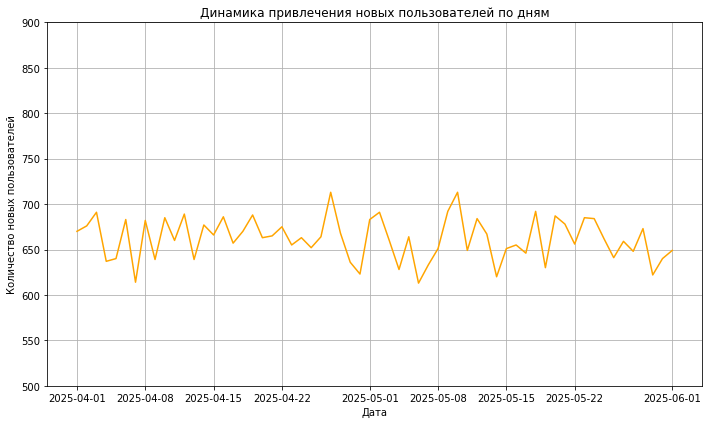

In [9]:
# Визуализируем динамику привлечения новых пользователей
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(new_users['first_dt'],new_users['user_id'],color='orange')

# Добавляем заголовок и подписи осей
plt.title('Динамика привлечения новых пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество новых пользователей')

# Добавляем сетку и границы оси y
plt.grid(True)
plt.ylim(500,900)
plt.tight_layout()

# Выводим график
plt.show()

#### Промежуточный вывод

Число новых пользователей остается стабильным в течение всего периода и колеблется в промежутке от 613 до 713 пользователей в день.

**Задача 2.2.** Анализ воронок событий.
- Построим классическую и пошаговую воронки;
- Охарактеризуем пользовательский путь в приложении и определим узкие места воронки. 


In [10]:
# Задаём порядок шагов в воронке
funnel_steps = ['install / open_web', 'introduction', 'registration', 'main_page', 'onboarding_complete', 'first_deposit', 'asset_purchase', 'second_deposit']

# Фильтруем датасет, оставляя только нужные шаги воронки
funnel_df_steps = hist_df[hist_df['event_name'].isin(funnel_steps)]

# Считаем число уникальных пользователей на каждом шаге
funnel_counts = funnel_df_steps.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)

# Собираем таблицу воронки
funnel_df = pd.DataFrame({
   'step': funnel_steps,
   'users': funnel_counts.values
})

In [11]:
# Считаем конверсию относительно первого шага
funnel_df['conversion_from_first_%'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)

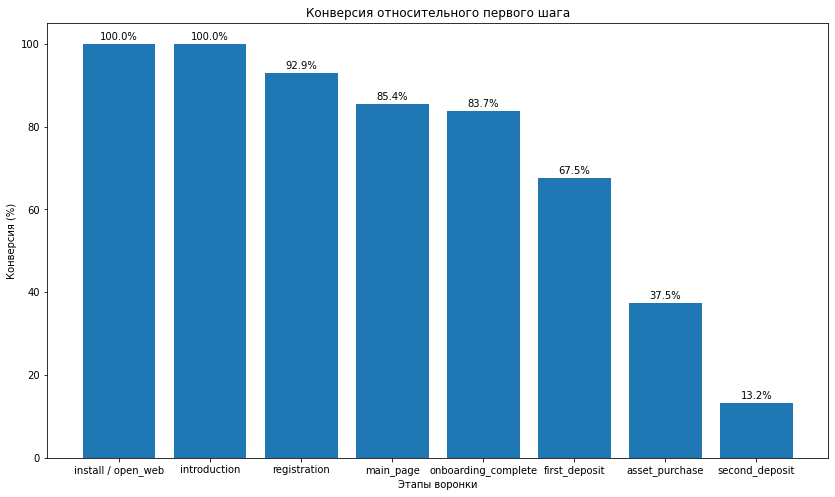

In [12]:
# Строим классическую воронку
# Визуализируем данные
plt.figure(figsize=(14, 8))

# Строим barplot
plt.bar(funnel_df['step'],funnel_df['conversion_from_first_%'])

# Добавляем подписи
for i, value in enumerate(funnel_df['conversion_from_first_%']):
    plt.text(i, value + 1, f'{value:.1f}%', ha='center')

# Добавляем заголовок и подписи осей
plt.title('Конверсия относительного первого шага')
plt.ylabel('Конверсия (%)')
plt.xlabel('Этапы воронки')

# Показываем график
plt.show()

На графике заметно резкое снижение числа пользователей на этапах покупки акций и повторного внесения депозита. Построим пошаговую воронку чтобы определить насколько значимо падение относительно предыдущего шага.

In [13]:
# Считаем конверсию относительно предыдущего шага
funnel_df['conversion_from_previous_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)

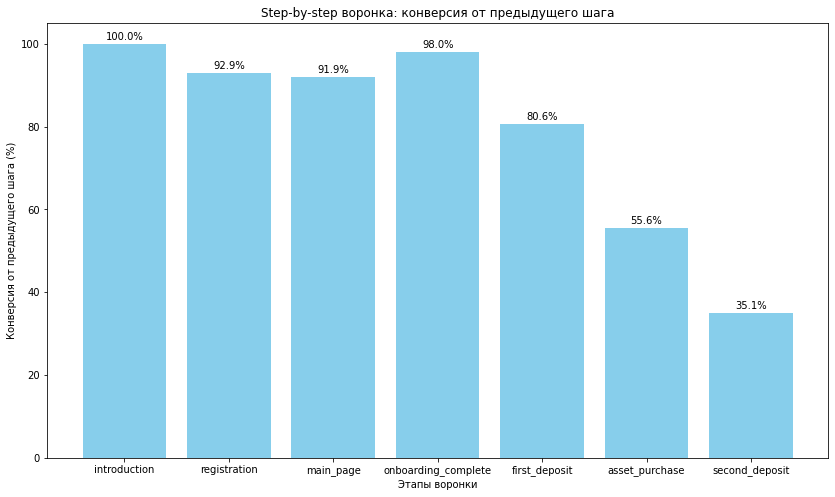

In [14]:
# Строим воронку step-by-step
# Убираем первый шаг, чтобы не выводить NaN
plot_df = funnel_df[funnel_df['step'] != 'install / open_web']

# Визуализируем данные 
plt.figure(figsize=(14, 8))

# Строим barplot
plt.bar(plot_df['step'], plot_df['conversion_from_previous_%'], color='skyblue')

# Добавляем подписи
for i, value in enumerate(plot_df['conversion_from_previous_%']):
    plt.text(i, value + 1, f'{value:.1f}%', ha='center')
    
# Добавляем заголовок и подписи осей
plt.title('Step-by-step воронка: конверсия от предыдущего шага')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')

# Показываем график
plt.show()

19,4% пользователей, которые прошли онбординг, не вносят первый депозит. Почти половина из тех, кто внес первый депозит, не покупают активы. И только 35% пользователей, купивших активы однажды, вносят повторный депозит.

**Задача 2.3.** Влияние уровня риска актива на открытие второго депозита. Изучим, как уровень риска первого актива влияет на конверсию во второй депозит.  

In [15]:
# Отфильтруем датасет и оставим только первую покупку актива для каждого пользователя
df_filtered_hist = hist_df[hist_df['event_name'] == 'asset_purchase'].groupby('user_id')['event_ts'].min().reset_index()

# Присоединяем уровень риска к отфильтрованному датафрейму
first_purchase = pd.merge(df_filtered_hist,hist_df[['user_id','event_ts','risk_level']],on=['user_id','event_ts'],how='inner')

In [16]:
# Группируем данные по уровню риска и считаем количество пользователей для каждого из них
first_purchase_users = first_purchase.groupby('risk_level')['user_id'].nunique().reset_index()

In [17]:
# Отбираем пользователей, которые внесли второй депозит
second_deposit_users = hist_df[hist_df['event_name'] == 'second_deposit']['user_id'].unique()

# Добавляем столбец в first_purchase, где True - пользователь внес повторный депозит, False - нет.
first_purchase['second_deposit'] = first_purchase['user_id'].isin(second_deposit_users)

In [18]:
# Считаем количество пользователей, которые внесли второй депозит, для каждого уровня риска
second_deposit_users = first_purchase.groupby('risk_level')['second_deposit'].sum().reset_index()

In [19]:
# Объединяем first_purchase_users и second_deposit_users по уровню риска для расчета конверсии
conversion_df = pd.merge(first_purchase_users,second_deposit_users,on='risk_level',how='inner')

# Считаем конверсию и округляем до двух знаков после точки
conversion_df['cr'] = round(((conversion_df['second_deposit']/conversion_df['user_id']) * 100),2)

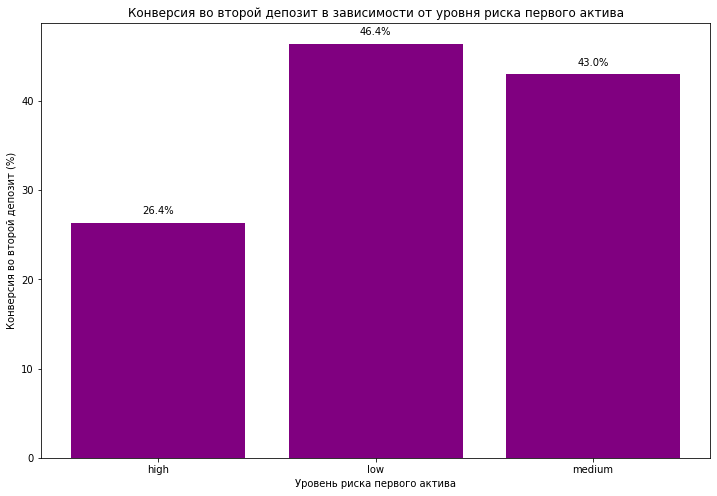

In [20]:
# Визуализируем конверсию во второй депозит по уровням риска
plt.figure(figsize=(12, 8))

# Строим столбчатую диаграмму
plt.bar(conversion_df['risk_level'], conversion_df['cr'], color='purple')

# Добавляем подписи
for i, value in enumerate(conversion_df['cr']): 
    plt.text(i, value + 1, f'{value:.1f}%', ha='center')

# Доавляем заголовок и подписи осей
plt.title('Конверсия во второй депозит в зависимости от уровня риска первого актива')
plt.xlabel('Уровень риска первого актива')
plt.ylabel('Конверсия во второй депозит (%)')

# Выводим график
plt.show()

#### Промежуточный вывод

Конверсия во второй депозит для пользователей, которые приобрели активы с высоким уровнем риска, значительно ниже, чем для пользователей с активами среднего и низкого риска: 26,4% против 46,4% и 43% соответственно. Это может свидетельствовать о том, что пользователи после покупки активов  с высоким уровнем риска реже возвращаются к повторному пополнению депозита. Возможной причиной может быть негативный пользовательский опыт и потеря денег после покупки таких активов.

Полученные результаты позволяют предположить, что уровень риска первого актива может быть одним из факторов, влияющих на удержание пользователей и повторные депозиты. При дальнейшем анализе A/B-теста стоит учитывать распределение пользователей по уровню риска, чтобы изменения в группах не были обусловлены различиями в составе аудитории.

**Задача 2.4.** Анализ ключевой метрики на исторических данных.
- На исторических данных рассчитаем значение ключевой метрики - средней суммы всех депозитов на одного пользователя. Учитывать будем всех пользователей, которые взаимодействовали с сервисом. Это позволит зафиксировать базовый уровень монетизации.
- Визуализируем данные, где необходимо. По результатам исследовательского анализа сделаем краткий вывод. 

In [21]:
# Считаем количество уникальных пользователей
total_users_hist = hist_df['user_id'].nunique()

# Суммируем депозиты
total_amount_hist = hist_df['amount'].sum()

# Считаем ключевую метрику (среднюю сумму всех депозитов на одного пользователя)
avg_amount_hist = round((total_amount_hist / total_users_hist),2)

# Выведем результат
avg_amount_hist

91.56

Для более детального понимания полученного значения метрики дополнительно рассмотрим распределение суммы депозитов на уровне отдельных пользователей. Это позволит оценить, насколько равномерно распределены депозиты и есть ли пользователи с существенно большими пополнениями, которые могут влиять на среднее значение.

In [22]:
# Заменим все пропуски в столбце 'amount' на 0, чтобы не исключить пользователей, которые не внесли ни одного депозита
hist_df['amount'] = hist_df['amount'].fillna(0)

# Считаем сумму депозитов на каждого пользователя
user_deposits = hist_df.groupby('user_id')['amount'].sum().reset_index()

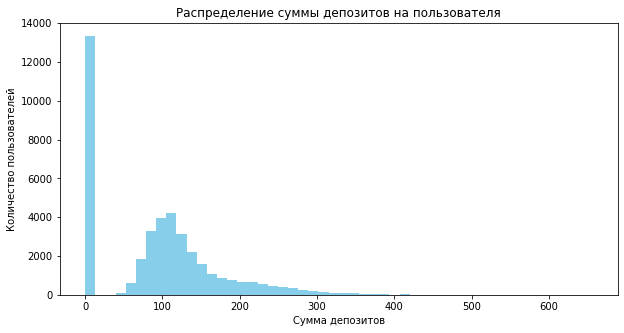

In [23]:
# Визуализируем распределение суммы депозитов на пользователя
# Задаем размер графика
plt.figure(figsize=(10, 5))

# Строим гистограмму
plt.hist(user_deposits['amount'], bins=50,color='skyblue')

# Доавляем заголовок и подписи осей
plt.title('Распределение суммы депозитов на пользователя')
plt.xlabel('Сумма депозитов')
plt.ylabel('Количество пользователей')

# Выводим график
plt.show()

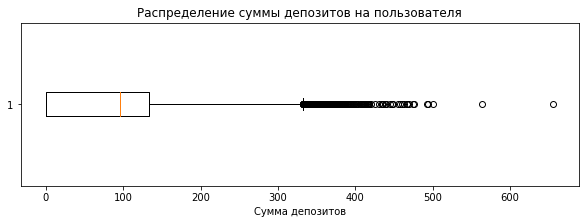

In [24]:
# Проверим наличие выбросов
plt.figure(figsize=(10, 3))

# Строим boxplot
plt.boxplot(user_deposits['amount'], vert=False)

# Добавляем подпись оси Х и заголовок
plt.xlabel('Сумма депозитов')
plt.title('Распределение суммы депозитов на пользователя')

# Показываем график
plt.show()

Средняя сумма депозитов на одного пользователя за исторический период составила 91,56. При этом распределение депозитов характеризуется сильной правосторонней асимметрией: значительная часть пользователей не совершала депозитов, а среди пользователей с пополнениями преобладают относительно небольшие суммы. Небольшое количество пользователей с крупными депозитами формирует значительную часть общего объема пополнений и влияет на среднее значение метрики.

### Общий промежуточный вывод

Анализ исторических данных показал, что поток новых пользователей в течение рассматриваемого периода оставался стабильным: количество регистраций не демонстрировало выраженного тренда и находилось в диапазоне 613-713 пользователей в день.

При анализе пользовательской воронки были выявлены наиболее критичные этапы взаимодействия с продуктом. Наибольшие потери пользователей происходят после прохождения онбординга, на этапе внесения первого депозита, а также при переходе от первой покупки активов к повторному пополнению счета. Только 80,6% пользователей после онбординга совершают первый депозит, около половины пользователей с первым депозитом переходят к покупке активов, а среди совершивших первую покупку лишь 35% возвращаются к повторному пополнению счета.

Дополнительно было выявлено влияние уровня риска приобретаемых активов на дальнейшее поведение пользователей. Конверсия во второй депозит среди пользователей, впервые купивших активы с высоким уровнем риска, составила 26,4%, что значительно ниже показателей для пользователей с активами среднего (46,4%) и низкого риска (43%). Это может указывать на возможную связь между негативным пользовательским опытом после покупки высокорисковых активов и снижением вероятности дальнейшего взаимодействия с продуктом. 

Анализ денежных метрик показал, что средняя сумма депозитов на пользователя за исторический период составила 91,56. При этом распределение депозитов характеризуется выраженной правосторонней асимметрией: большая часть пользователей либо не совершает депозитов, либо вносит относительно небольшие суммы, тогда как небольшая группа пользователей с крупными пополнениями формирует значительную долю общего объема депозитов.

---

## Часть 2

### 3. Исследование результатов А/В эксперимента

Загрузим данные с результатами эксперимента. Проверим корректность данных и проведем предобработку. Основную информацию о данных и предобработке зафиксируем в кратком промежуточном выводе.
Затем проведем анализ результатов А/В-эксперимента.


In [25]:
# Выгрузим данные с результатами эксперимента из датасета и сохраним их в новой переменной df
df = pd.read_csv('https://code.s3.yandex.net/datasets/pa_sollmafin_abt.csv')

In [26]:
# Выведем первые строки датафрейма
df.head()

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,ab_test,group,amount,asset,risk_level
0,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:51,install / open_web,onboarding_test,test,NaN,NaN,NaN
1,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:54,introduction,onboarding_test,test,NaN,NaN,NaN
2,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:09,registration,onboarding_test,test,NaN,NaN,NaN
3,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:13,main_page,onboarding_test,test,NaN,NaN,NaN
4,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:33:40,onboarding_complete,onboarding_test,test,NaN,NaN,NaN


In [27]:
# Выведем информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54805 entries, 0 to 54804
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       54805 non-null  object 
 1   country_code  54805 non-null  object 
 2   platform      54805 non-null  object 
 3   first_ts      54805 non-null  object 
 4   first_dt      54805 non-null  object 
 5   event_ts      54805 non-null  object 
 6   event_name    54805 non-null  object 
 7   ab_test       54805 non-null  object 
 8   group         54805 non-null  object 
 9   amount        7843 non-null   float64
 10  asset         3750 non-null   object 
 11  risk_level    3750 non-null   object 
dtypes: float64(1), object(11)
memory usage: 5.0+ MB


Также как и в случае с историческими данными, пропуски содержатся только в столбцах amount, asset и risk_level. Они объясняются тем, что не все события предпологают пополнение депозита или совершение покупки актива пользователем. Поэтому пропуски обрабатывать мы не будем. Проверим датафрейм на наличие дублирующихся значений.

In [28]:
# Проверяем наличие явных дубликатов
df.duplicated().sum()

0

In [29]:
# Проверяем наличие неявных дубликатов по столбцам user_id, platform, event_name и event_ts
df[['user_id','platform','event_name','event_ts']].duplicated().sum()

0

In [30]:
# Приведем данные в столбцах first_ts, first_dt и event_ts к типу datetime
df['first_ts'] = pd.to_datetime(df['first_ts'])
df['first_dt'] = pd.to_datetime(df['first_dt'])
df['event_ts'] = pd.to_datetime(df['event_ts'])

In [31]:
# Проверим, есть ли в датасете пользователи, которые участвовали в других тестах
df['ab_test'].unique()

array(['onboarding_test'], dtype=object)

In [32]:
# Проверим, нет ли в данных других групп, помимо тестовой и контрольной
df['group'].unique()

array(['test', 'control'], dtype=object)

#### Промежуточный вывод

Датафрейм содержит 54805 строк и 12 столбцов. Данные соответствуют описанию.

Пропуски присутствуют в столбцах с данными о пополнениях депозита и о покупках активов, но только для тех событий, где пополнение депозита или покупка не могли совершится. Поэтому, пропуски мы никак не обрабатывали.

Явные и неявные дублирующиеся значения в датафрейме отсутствуют.

 
Значения в столбцах `first_ts`, `first_dt` и `event_ts` мы привели к типу даты и времени `datetime`. Данные в остальных столбцах хранятся в правильном типе.

В датафрейме хранятся данные только о интересующем нас тесте (`onboarding_test`) и есть только 2 группы (`test` и `control`).

**Задача 3.1.** Анализ аудитории эксперимента. 
- Проверим корректность распределения новых пользователей по группам А/В-эксперимента. 
- Построим графики и сформулируем промежуточный вывод. 

In [33]:
# Посчитаем количество уникальных пользователей в каждой из групп
group_users = df.groupby('group')['user_id'].nunique().reset_index()

# Посмотрим, в каком процентном соотношении они находятся:
group_users['share'] = group_users['user_id'] / group_users['user_id'].sum()

# Выведем результат
group_users

,group,user_id,share
0,control,4847,0.514817
1,test,4568,0.485183


Расхождение, кажется,  небольшое, и им можно пренебречь. Тем не менее стоит проверить, возможно, дело в пользователях, которые могли попасть в обе группы.

In [34]:
# Создаем переменные, в которых будут хранится пользователи из тестовой и контрольной групп
test = df[df['group'] == 'test']['user_id']
control = df[df['group'] == 'control']['user_id']

# Проверяем есть ли пересечения
intersection = list(set(test) & set(control))

# Выводим результат
intersection

[]

Пользователи, которые попали в обе группы, отсутствуют. Проверим распределение новых пользователей по дням.

In [35]:
# Считаем количество новых пользователей по дням
new_users_abt = df.groupby(['first_dt','group'])['user_id'].nunique().reset_index()

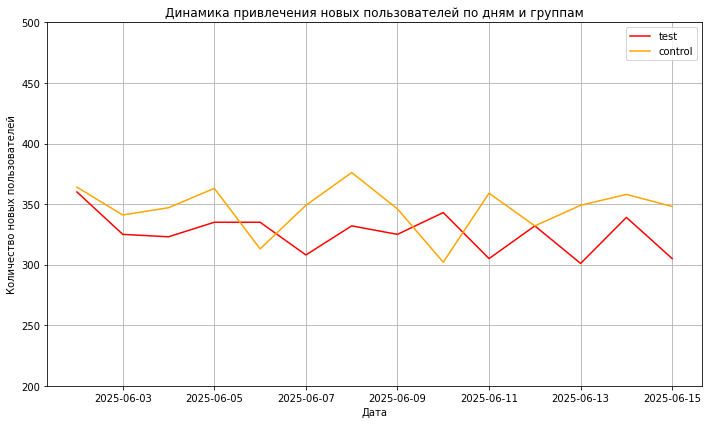

In [36]:
# Визуализируем динамику привлечения новых пользователей
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(new_users_abt[new_users_abt['group'] == 'test']['first_dt'],new_users_abt[new_users_abt['group'] == 'test']['user_id'],color='red',label='test')
plt.plot(new_users_abt[new_users_abt['group'] == 'control']['first_dt'],new_users_abt[new_users_abt['group'] == 'control']['user_id'],color='orange',label='control')

# Добавляем заголовок и подписи осей
plt.title('Динамика привлечения новых пользователей по дням и группам')
plt.xlabel('Дата')
plt.ylabel('Количество новых пользователей')

# Добавляем сетку и границы оси y
plt.grid(True)
plt.legend()
plt.ylim(200,500)
plt.tight_layout()

# Выводим график
plt.show()

Распределение новых пользователей по дням остается стабильным в группах. Значения находятся в диапазоне от 301 до 360 пользователей в тестовой группе и от 302 до 376 в контрольной группе. 

In [37]:
# Проверим распределение пользователей по странам
country_users = df.groupby(['group', 'country_code'])['user_id'].nunique().reset_index()

# Выведем результат
country_users

,group,country_code,user_id
0,control,AR,756
1,control,BR,1543
2,control,CO,1247
3,control,MX,1301
4,test,AR,725
5,test,BR,1448
6,test,CO,1199
7,test,MX,1196


Пользователи по странам распределены примерно одинаково между группами. 

#### Промежуточный вывод

Пользователи распределены между группами практически равномерно: 51,5% в контрольной группе и 48,5% в тестовой группе. Динамика привлечения новых пользователей по дням в обеих группах схожа, существенных разрывов не наблюдается. Распределение пользователей по странам также не имеет выраженных различий. Это позволяет считать рандомизацию корректной и переходить к анализу результатов эксперимента.

**Задача 3.2.** Сравнение воронок событий.
- Сравним пользовательский путь новых пользователей в тестовой и контрольной группах.
- Построим классическую и последовательную воронки, выполним визуализацию и сделаем промежуточный вывод. 

In [38]:
# Создаем два отдельных датафрейма для контрольной и тестовой групп
control_df = df[df['group'] == 'control'].copy()
test_df = df[df['group'] == 'test'].copy()

Проводим вычисления конверсий на каждом шаге воронки для контрольной группы.

In [39]:
# Фильтруем датасет, оставляя только нужные шаги воронки
funnel_control_steps = control_df[control_df['event_name'].isin(funnel_steps)]

# Считаем число уникальных пользователей на каждом шаге
funnel_control_counts = funnel_control_steps.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)

# Собираем таблицу воронки для контрольной группы
funnel_control = pd.DataFrame({
   'step': funnel_steps,
   'users': funnel_control_counts.values
})

In [40]:
# Считаем конверсию относительно первого шага для контрольной группы
funnel_control['conversion_from_first_%'] = (funnel_control['users'] / funnel_control['users'].iloc[0] * 100).round(1)

Проводим вычисления конверсий на каждом шаге воронки для тестовой группы.

In [41]:
# Фильтруем датасет, оставляя только нужные шаги воронки
funnel_test_steps = test_df[test_df['event_name'].isin(funnel_steps)]

# Считаем число уникальных пользователей на каждом шаге
funnel_test_counts = funnel_test_steps.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)

# Собираем таблицу воронки для тестовой группы
funnel_test = pd.DataFrame({
   'step': funnel_steps,
   'users': funnel_test_counts.values
})

In [42]:
# Считаем конверсию относительно первого шага для тестовой группы
funnel_test['conversion_from_first_%'] = (funnel_test['users'] / funnel_test['users'].iloc[0] * 100).round(1)

Строим визуализацию классической воронки для контрольной и тестовой групп на одном графике. 

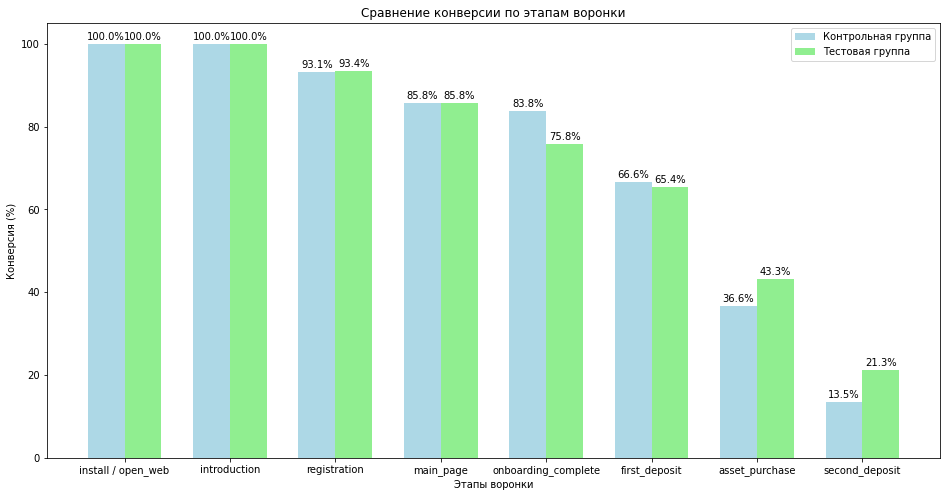

In [43]:
# Задаем размер графика
plt.figure(figsize=(16, 8))

# Определяем позиции этапов воронки на оси X
x = np.arange(len(funnel_control['step']))

width = 0.35

# Строим столбцы для контрольной группы
plt.bar(x - width/2, funnel_control['conversion_from_first_%'], width, label='Контрольная группа',color='lightblue')

# Строим столбцы для тестовой группы
plt.bar(x + width/2, funnel_test['conversion_from_first_%'], width, label='Тестовая группа', color='lightgreen')

# Добавляем подписи значений над столбцами контрольной группы
for i, value in enumerate(funnel_control['conversion_from_first_%']):
    plt.text(i - width/2, value + 1, f'{value:.1f}%', ha='center')

# Добавляем подписи значений над столбцами тестовой группы
for i, value in enumerate(funnel_test['conversion_from_first_%']):
    plt.text(i + width/2, value + 1, f'{value:.1f}%', ha='center')

# Настраиваем названия этапов на оси X
plt.xticks(x, funnel_control['step'])

# Добавляем заголовок и подписи осей
plt.title('Сравнение конверсии по этапам воронки')
plt.ylabel('Конверсия (%)')
plt.xlabel('Этапы воронки')

# Добавляем легенду для групп
plt.legend()

# Показываем график
plt.show()

На всех шагах, до внесения первого депозита, конверсия практически не различается. Однако на этапах покупки акций и внесения повторного депозита конверсия в тестовой группе выше, чем в контрольной.

На этапе покупки акции конверсия в тестовой группе составляет 43,3% против 36,6% в контрольной. На этапе повторного внесения депозита значения принимают 21,3% и 13,5% соответственно.

Посмотрим, как изменилась конверсия в пошаговой воронке.

In [44]:
# Считаем конверсию относительно предыдущего шага для контрольной группы
funnel_control['conversion_from_previous_%'] = (funnel_control['users'] / funnel_control['users'].shift(1) * 100).round(1)

In [45]:
# Считаем конверсию относительно предыдущего шага для тестовой группы
funnel_test['conversion_from_previous_%'] = (funnel_test['users'] / funnel_test['users'].shift(1) * 100).round(1)

Визуализируем пошаговую воронку для контрольной и тестовой групп на одном графике.

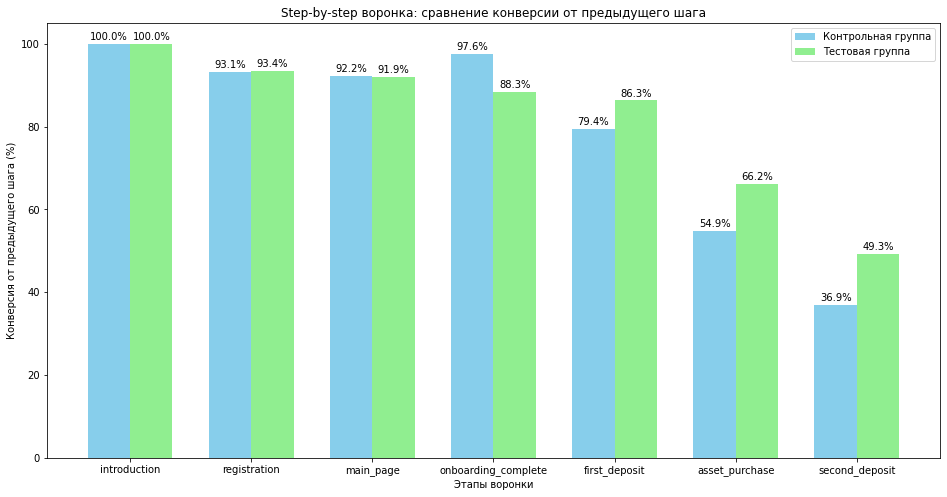

In [46]:
# Убираем первый шаг, чтобы не выводить NaN
plot_df_control = funnel_control[funnel_control['step'] != 'install / open_web']
plot_df_test = funnel_test[funnel_test['step'] != 'install / open_web']

# # Задаем размер графика
plt.figure(figsize=(16, 8))

# Определяем позиции этапов воронки на оси X
x = np.arange(len(plot_df_control['step']))
# Задаём ширину столбцов
width = 0.35

# Строим столбцы для контрольной группы
plt.bar(x - width/2, plot_df_control['conversion_from_previous_%'], width, label='Контрольная группа', color='skyblue')
# Строим столбцы для тестовой группы
plt.bar(x + width/2, plot_df_test['conversion_from_previous_%'], width, label='Тестовая группа', color='lightgreen')

# Добавляем подписи значений над столбцами контрольной группы
for i, value in enumerate(plot_df_control['conversion_from_previous_%']):
    plt.text(i - width/2, value + 1, f'{value:.1f}%', ha='center')
# Добавляем подписи значений над столбцами тестовой группы
for i, value in enumerate(plot_df_test['conversion_from_previous_%']):
    plt.text(i + width/2, value + 1, f'{value:.1f}%', ha='center')

# Настраиваем названия этапов на оси X
plt.xticks(x, plot_df_control['step'])

# Добавляем заголовок и подписи осей
plt.title('Step-by-step воронка: сравнение конверсии от предыдущего шага')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')

# Добавляем легенду
plt.legend()

# Показываем график
plt.show()

В пошаговой воронке, значения конверсии в тестовой группе на этапах покупки акций и внесения второго депозита также выше, чем в контрольной. Акции покупают уже 66,2% пользователей, внесших первый депозит, и почти половина затем вносят депозит повторно. 
Однако, стоит заметить, что онбординг теперь проходят меньше пользователей из тестовой группы, чем из контрольной - всего 88,3% вместо 97,6%. 

#### Промежуточный вывод

Анализ классической и пошаговой воронок показал, что влияние изменений неоднозначно и проявляется на разных этапах пользовательского пути. До этапа внесения первого депозита конверсия в контрольной и тестовой группах практически не отличается, за исключением этапа онбординга, где тестовая группа показывает более низкую конверсию (88,3% против 97,6%). При этом на последующих этапах тестовая группа демонстрирует более высокие показатели. Конверсия в покупку акций относительно первого шага составляет 43,3% против 36,6% в контрольной группе, а конверсия в повторный депозит - 21,3% против 13,5%. Аналогичная тенденция наблюдается и в пошаговой воронке: после внесения первого депозита акции приобретают 66,2% пользователей тестовой группы, а почти половина из них затем совершают повторный депозит. 

**Задача 3.3.** Влияние новой фичи на конверсию во второй депозит с учётом уровня риска купленного актива.
- Проанализируем, как категория риска купленного актива влияет на вероятность открытия второго депозита в тестовой и контрольной группах. 
- Сравним результаты и оценим, есть ли статистически значимая разница между группами. 

Рассчитаем конверсию во второй депозит с учётом уровня риска купленного актива отдельно для контрольной и тестовой групп.

In [47]:
# Отфильтруем датасет и оставим только первую покупку актива для каждого пользователя и контрольную группу
df_filtered_control = df[(df['event_name'] == 'asset_purchase') & (df['group'] == 'control')].groupby('user_id')['event_ts'].min().reset_index()

# Присоединяем уровень риска к отфильтрованному датафрейму
first_purchase_control = pd.merge(df_filtered_control,df[['user_id','event_ts','risk_level']],on=['user_id','event_ts'],how='inner')

# Группируем данные по уровню риска и считаем количество пользователей для каждого из них
first_purchase_users_control = first_purchase_control.groupby('risk_level')['user_id'].nunique().reset_index()

# Отбираем пользователей, которые внесли второй депозит
second_deposit_users_control = df[(df['event_name'] == 'second_deposit') & (df['group'] == 'control')]['user_id'].unique()

# Добавляем столбец в first_purchase_control, где True - пользователь внес повторный депозит, False - нет.
first_purchase_control['second_deposit'] = first_purchase_control['user_id'].isin(second_deposit_users_control)

# Считаем количество пользователей, которые внесли второй депозит, для каждого уровня риска
second_deposit_users_control = first_purchase_control.groupby('risk_level')['second_deposit'].sum().reset_index()

# Объединяем first_purchase_users_control и second_deposit_users_control по уровню риска для расчета конверсии
conversion_df_control = pd.merge(first_purchase_users_control,second_deposit_users_control,on='risk_level',how='inner')

# Считаем конверсию для контрольной группы и округляем до двух знаков после точки
conversion_df_control['cr'] = round(((conversion_df_control['second_deposit']/conversion_df_control['user_id']) * 100),2)

In [48]:
# Отфильтруем датасет и оставим только первую покупку актива для каждого пользователя и тестовую группу
df_filtered_test = df[(df['event_name'] == 'asset_purchase') & (df['group'] == 'test')].groupby('user_id')['event_ts'].min().reset_index()

# Присоединяем уровень риска к отфильтрованному датафрейму
first_purchase_test = pd.merge(df_filtered_test,df[['user_id','event_ts','risk_level']],on=['user_id','event_ts'],how='inner')

# Группируем данные по уровню риска и считаем количество пользователей для каждого из них
first_purchase_users_test = first_purchase_test.groupby('risk_level')['user_id'].nunique().reset_index()

# Отбираем пользователей, которые внесли второй депозит
second_deposit_users_test = df[(df['event_name'] == 'second_deposit') & (df['group'] == 'test')]['user_id'].unique()

# Добавляем столбец в first_purchase_test, где True - пользователь внес повторный депозит, False - нет.
first_purchase_test['second_deposit'] = first_purchase_test['user_id'].isin(second_deposit_users_test)

# Считаем количество пользователей, которые внесли второй депозит, для каждого уровня риска
second_deposit_users_test = first_purchase_test.groupby('risk_level')['second_deposit'].sum().reset_index()

# Объединяем first_purchase_users_control и second_deposit_users_control по уровню риска для расчета конверсии
conversion_df_test = pd.merge(first_purchase_users_test,second_deposit_users_test,on='risk_level',how='inner')

# Считаем конверсию для контрольной группы и округляем до двух знаков после точки
conversion_df_test['cr'] = round(((conversion_df_test['second_deposit']/conversion_df_test['user_id']) * 100),2)

Визуализируем показатели для обеих групп на одном графике.

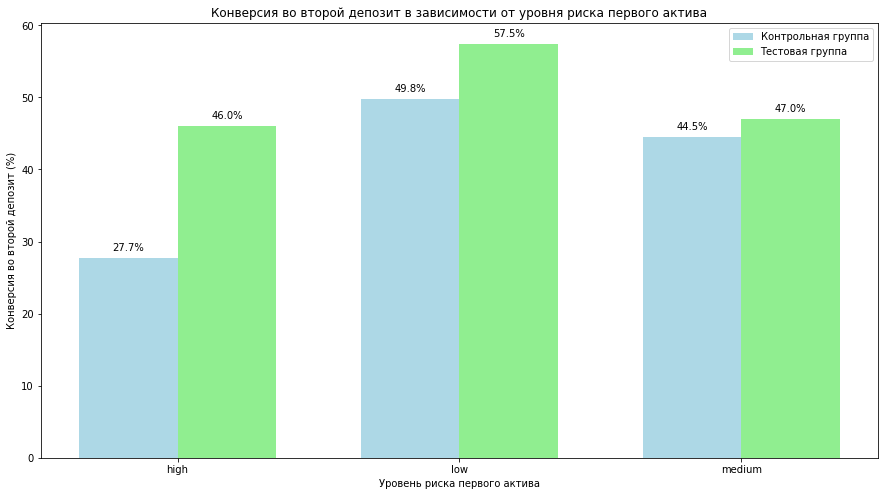

In [49]:
# Задаем размер графика
plt.figure(figsize=(15, 8))

# Определяем позиции уровней риска на оси X
x = np.arange(len(conversion_df_control['risk_level']))
# Задаём ширину столбцов
width = 0.35

# Строим столбцы для контрольной группы
plt.bar(x - width/2, conversion_df_control['cr'], width, label='Контрольная группа', color='lightblue')
# Строим столбцы для тестовой группы
plt.bar(x + width/2, conversion_df_test['cr'], width, label='Тестовая группа', color='lightgreen')

# Добавляем подписи значений для контрольной группы
for i, value in enumerate(conversion_df_control['cr']):
    plt.text(i - width/2, value + 1, f'{value:.1f}%', ha='center')
# Добавляем подписи значений для тестовой группы
for i, value in enumerate(conversion_df_test['cr']):
    plt.text(i + width/2, value + 1, f'{value:.1f}%', ha='center')

# Настраиваем названия уровней риска на оси X
plt.xticks(x, conversion_df_control['risk_level'])

# Добавляем заголовок и подписи осей
plt.title('Конверсия во второй депозит в зависимости от уровня риска первого актива')
plt.xlabel('Уровень риска первого актива')
plt.ylabel('Конверсия во второй депозит (%)')

# Добавляем легенду
plt.legend()

# Показываем график
plt.show()

Конверсия на всех уровнях риска у тестовой группы выше, чем в контрольной группе. Перед тем, как сделать выводы, проверим, есть ли статистически значимая разница между группами, с помощью z-теста пропорций. Для оценки результата будет использовать уровнь значимости, равный 0.05.

In [50]:
# Зададим уровни риска
risk_levels = ['high', 'low', 'medium']

# Создадим цикл, чтобы посчитать количество успехов и общее число наблюдений для каждого уровня риска:
for risk in risk_levels:
    # Фильтруем контрольную и тестовую группы по уровням риска
    control = conversion_df_control[conversion_df_control['risk_level'] == risk]
    test = conversion_df_test[conversion_df_test['risk_level'] == risk]
    # Считаем количество успехов и общее количество наблюдений
    count = [control['second_deposit'].iloc[0], test['second_deposit'].iloc[0]]
    nobs = [control['user_id'].iloc[0], test['user_id'].iloc[0]]
    # Проводим z-тест пропорций
    stat, p = proportions_ztest(count, nobs)


    print(risk, p)

high 1.6045267948760416e-14
low 0.03907219043785841
medium 0.3606904739384701


#### Промежуточный вывод

Анализ показал, что влияние тестового изменения зависит от категории риска актива. Для пользователей с активами высокого риска наблюдается статистически значимое увеличение вероятности открытия второго депозита: конверсия выросла с 27.66% в контрольной группе до 46.00% в тестовой группе.

Для категории low также обнаружено статистически значимое увеличение конверсии: с 49.82% до 57.46%.

Для категории medium статистически значимых различий между тестовой и контрольной группами не выявлено: рост с 44.54% до 47.04% не является статистически подтверждённым (p-value больше уровня значимости).

**Задача 3.4.** Анализ метрик А/В-эксперимента. Проанализируем такие метрики:
- Ключевая метрика — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию).
- Барьерная метрика — конверсия из регистрации в первый депозит.
- Вспомогательная метрика 1 — конверсия из первого депозита во второй.
- Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.

Для каждой метрики выведем: 
- значения в контрольной и тестовой группах, 
- абсолютные и относительные изменения значений в тестовой группе по сравнению с контрольной.

После этого проверим статистическую значимость различий метрик между группами эксперимента. 

Для ключевой метрики также изучим:
- накопленную динамику изменения по дням эксперимента для каждой группы, 
- стабильность p-value во время эксперимента.

In [51]:
# Рассчитываем ключевую метрику, а также абсолютные и относительные изменения значений в тестовой группе по сравнению с контрольной
# Считаем количество уникальных пользователей
total_users = df.groupby('group')['user_id'].nunique()

# Суммируем депозиты
total_amount = df.groupby('group')['amount'].sum()

# Считаем ключевую метрику (среднюю сумму всех депозитов на одного пользователя)
avg_amount = round((total_amount / total_users),2)

# Рассчитаем изменения ключевой метрики в абсолютном и относительном значениях
kpi_diff_abs = round((avg_amount['test'] -  avg_amount['control']),2)
kpi_diff_rel = round((avg_amount['test'] - avg_amount['control']) / avg_amount['control'] * 100, 2)

# Выведем результат
print('Значение ключевой метрики в контрольной группе:', avg_amount['control'])
print('Значение ключевой метрики в тестовой группе:', avg_amount['test'])
print('Абсолютная разница:', kpi_diff_abs)
print('Относительная разница:', kpi_diff_rel, '%')

Значение ключевой метрики в контрольной группе: 90.24
Значение ключевой метрики в тестовой группе: 92.46
Абсолютная разница: 2.22
Относительная разница: 2.46 %


In [52]:
# Проводим t-тест Уэлча для ключевой метрики: средняя сумма всех депозитов на одного пользователя
# Копируем датафрейм, чтобы не внести изменения в исходный
copy_df = df.copy()

# Заменяем пропуски в amount на 0, чтобы включить всех пользователей
copy_df['amount'] = copy_df['amount'].fillna(0)

# Получим метрику для каждого пользователя
user_amount = copy_df.groupby(['group', 'user_id'])['amount'].sum().reset_index()

# Разделим данные на группы
control = user_amount[user_amount['group'] == 'control']['amount']
test = user_amount[user_amount['group'] == 'test']['amount']

# Проводим t-тест Уэлча
_, p = ttest_ind(control, test, equal_var=False)

# Задаем уровень значимости
alpha = 0.05

# Интерпретируем результат
if p < alpha:
    print(f'Различия статистически значимы, p-value равно {p}')
else:
    print(f'Статистически значимых различий нет, p-value равно {p}')

Статистически значимых различий нет, p-value равно 0.33829488891764226


Ключевая метрика (средняя сумма всех депозитов на одного пользователя ) в тестовой группе выросла на 2.46% по сравнению с контрольной. Однако этот рост не является статистически значимым.

In [53]:
# Рассчитываем барьерную метрику, а также абсолютные и относительные изменения значений в тестовой группе по сравнению с контрольной
# Считаем количество уникальных пользователей, которые зарегестрировались, для каждой группы
registered_users = df[df['event_name'] == 'registration'].groupby('group')['user_id'].nunique()

# Считаем количество уникальных пользователей, которые внесли первый депозит, для каждой группы
first_deposit_users = df[df['event_name'] == 'first_deposit'].groupby('group')['user_id'].nunique()

# Считаем конверсию из регистрации в первый депозит для каждой группы
groups_cr = first_deposit_users / registered_users

# Считаем разницу между тестовой и контрольной группой в абсолютном и относительном значениях
cr_diff_abs = round((groups_cr['test'] -  groups_cr['control']),2)
cr_diff_rel = round((groups_cr['test'] - groups_cr['control']) / groups_cr['control'] * 100, 2)

# Выведем результат
print('Значение барьерной метрики в контрольной группе:', groups_cr['control'])
print('Значение барьерной метрики в тестовой группе:', groups_cr['test'])
print('Абсолютная разница:', cr_diff_abs)
print('Относительная разница:', cr_diff_rel, '%')

Значение барьерной метрики в контрольной группе: 0.7154255319148937
Значение барьерной метрики в тестовой группе: 0.7003516998827667
Абсолютная разница: -0.02
Относительная разница: -2.11 %


In [54]:
# Проводим z-тест пропорций для барьерной метрики: конверсия из регистрации в первый депозит
# Определяем число успехов и общее число наблюдений
count = [first_deposit_users['control'], first_deposit_users['test']]
nobs = [registered_users['control'], registered_users['test']]

# Считаем p-value с помощью z-теста пропорций
_, p = proportions_ztest(count, nobs)


# Задаем уровень значимости
alpha = 0.05

# Интерпретируем результат
if p < alpha:
    print(f'Различия статистически значимы, p-value равно {p}')
else:
    print(f'Статистически значимых различий нет, p-value равно {p}')

Статистически значимых различий нет, p-value равно 0.12054344809112846


Барьерная метрика (конверсия из регистрации в первый депозит) упала на 2.11%, но эта разница также не значима статистически.

In [55]:
# Рассчитываем вспомогательную метрику №1: Конверсия из первого депозита во второй
# Считаем количество пользователей, которые внесли первый депозит
first_deposit_count = df[df['event_name'] == 'first_deposit'].groupby('group')['user_id'].nunique()

# Считаем количество пользователей, которые внесли второй депозит
second_deposit_count = df[df['event_name'] == 'second_deposit'].groupby('group')['user_id'].nunique()

# Считаем конверсию из первого депозита во второй по группам
second_deposit_sr = second_deposit_count/first_deposit_count

# Считаем разницу между тестовой и контрольной группой в абсолютном и относительном значениях
second_cr_diff_abs = round((second_deposit_sr['test'] -  second_deposit_sr['control']),2)
second_cr_diff_rel = round((second_deposit_sr['test'] - second_deposit_sr['control']) / second_deposit_sr['control'] * 100, 2)

# Выведем результат
print('Значение вспомогательной метрики №1 в контрольной группе:', second_deposit_sr['control'])
print('Значение вспомогательной метрики №1 в тестовой группе:', second_deposit_sr['test'])
print('Абсолютная разница:', second_cr_diff_abs)
print('Относительная разница:', second_cr_diff_rel, '%')

Значение вспомогательной метрики №1 в контрольной группе: 0.20260223048327136
Значение вспомогательной метрики №1 в тестовой группе: 0.3260796786072983
Абсолютная разница: 0.12
Относительная разница: 60.95 %


In [56]:
# Проводим z-тест пропорций для вспомогательной метрики №1: конверсия из первого депозита во второй
# Определяем число успехов и общее число наблюдений
count = [second_deposit_count['control'], second_deposit_count['test']]
nobs = [first_deposit_count['control'], first_deposit_count['test']]

# Считаем p-value с помощью z-теста пропорций
_, p = proportions_ztest(count, nobs)


# Задаем уровень значимости
alpha = 0.05

# Интерпретируем результат
if p < alpha:
    print(f'Различия статистически значимы, p-value равно {p}')
else:
    print(f'Статистически значимых различий нет, p-value равно {p}')

Различия статистически значимы, p-value равно 1.9355885675373928e-28


Со вспомогательной метрикой №1 (конверсия из первого депозита во второй) ситуация другая: результат можно считать статистически значимым. Метрика выросла на 60.95%.

In [57]:
# Рассчитывем вспомогательную метрику №2: Средняя сумма всех депозитов среди пользователей, которые открыли хотя бы один депозит
# Фильтруем пользователей, которые внесли хотя бы 1 депозит и сразу считаем их количество
deposit_users = df[df['amount'].notna()].groupby('group')['user_id'].nunique()

# Считаем сумму всех депозитов по группам
# Не фильтруем датафрейм, так как сумма есть только в столбцах с депозитами
sum_amount = df.groupby('group')['amount'].sum()

# Считаем метрику по группам
avg_amount_deposit = sum_amount/deposit_users

# Считаем разницу между тестовой и контрольной группой в абсолютном и относительном значениях
avg_amount_diff_abs = round((avg_amount_deposit['test'] -  avg_amount_deposit['control']),2)
avg_amount_diff_rel = round((avg_amount_deposit['test'] - avg_amount_deposit['control']) / avg_amount_deposit['control'] * 100, 2)

# Выведем результат
print('Значение вспомогательной метрики №2 в контрольной группе:', avg_amount_deposit['control'])
print('Значение вспомогательной метрики №2 в тестовой группе:', avg_amount_deposit['test'])
print('Абсолютная разница:', avg_amount_diff_abs)
print('Относительная разница:', avg_amount_diff_rel, '%')

Значение вспомогательной метрики №2 в контрольной группе: 135.5
Значение вспомогательной метрики №2 в тестовой группе: 141.39973217274857
Абсолютная разница: 5.9
Относительная разница: 4.35 %


In [58]:
# Проводим t-тест Уэлча для вспомогательной метрики №2: средняя сумма всех депозитов среди пользователей, которые открыли хотя бы один депозит
# Оставим только пользователей с депозитами
deposit_df = df[df['amount'].notna()]

# Получим метрику для каждого пользователя
user_amount_2 = deposit_df.groupby(['group', 'user_id'])['amount'].sum().reset_index()

# Разделим данные на группы
control = user_amount_2[user_amount_2['group'] == 'control']['amount']
test = user_amount_2[user_amount_2['group'] == 'test']['amount']

# Проводим t-тест Уэлча
_, p = ttest_ind(control, test, equal_var=False)

# Задаем уровень значимости
alpha = 0.05

# Интерпретируем результат
if p < alpha:
    print(f'Различия статистически значимы, p-value равно {p}')
else:
    print(f'Статистически значимых различий нет, p-value равно {p}')

Различия статистически значимы, p-value равно 0.040038687957718415


Анологично с предыдущей метрикой, различия также статистически значимы. Вспомогательная метрика №2 (средняя сумма всех депозитов среди пользователей, которые открыли хотя бы один депозит) выросла на 4.35%.

Для ключевой метрики рассчитаем и визуализируем накопленную динамику по дням.

In [59]:
# Рассчитываем ключевую метрику по дням и по группам
# Добавляем новый столбец с днем из event_ts
df['date'] = df['event_ts'].dt.date

# Считаем количество уникальных пользователей по дням и группам
total__daily_users = df.groupby(['date','group'])['user_id'].nunique().reset_index()

# Суммируем депозиты по дням и группам
total_daily_amount = df.groupby(['date','group'])['amount'].sum().reset_index()

# Объединяем количество пользователей и суммы депозитов
avg_daily_amount = pd.merge(total__daily_users,total_daily_amount,on=['date','group'],how='inner')

# Считаем ключевую метрику (среднюю сумму всех депозитов на одного пользователя) по дням и группам
avg_daily_amount['avg_amount'] = round((avg_daily_amount['amount'] / avg_daily_amount['user_id']),2)

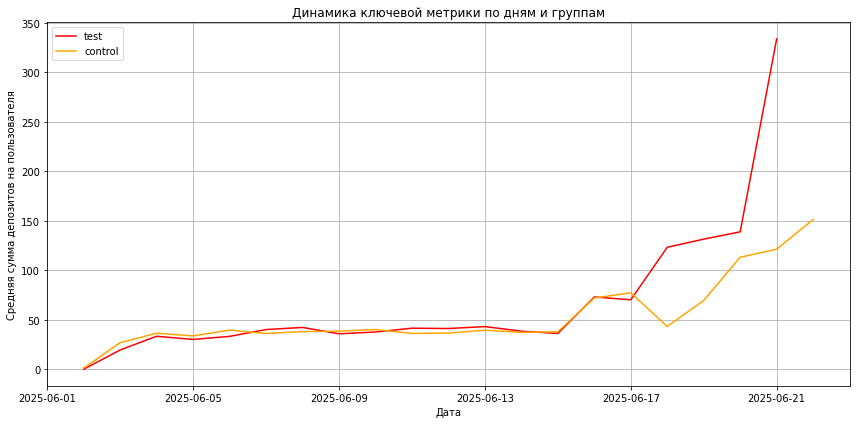

In [60]:
# Строим график чтобы визуализировать накопленную динамику ключевой метрики по дням
# Задаем размер графика
plt.figure(figsize=(12, 6))

# Строим график
plt.plot(avg_daily_amount[avg_daily_amount['group'] == 'test']['date'],avg_daily_amount[avg_daily_amount['group'] == 'test']['avg_amount'],color='red',label='test')
plt.plot(avg_daily_amount[avg_daily_amount['group'] == 'control']['date'],avg_daily_amount[avg_daily_amount['group'] == 'control']['avg_amount'],color='orange',label='control')

# Добавляем заголовок и подписи осей
plt.title('Динамика ключевой метрики по дням и группам')
plt.xlabel('Дата')
plt.ylabel('Средняя сумма депозитов на пользователя')

# Добавляем сетку и легенду
plt.grid(True)
plt.legend()
plt.tight_layout()

# Выводим график
plt.show()

В течение первых двух недель, а точнее до 17 июня, ключевая метрика в обеих группах была примерной на одном уровне. Но к концу эксперимента показатели в тестовой группе начали превышать значения в контрольной.

In [61]:
# Создаем список с датами эксперимента
dates = sorted(df['date'].unique())

# Создаем пустой список
results = []

# Создаем цикл чтобы для каждого дня посчитать накопленные данные
for date in dates:
    # Берем все события до текущей даты включительно
    cumulative_df = df[df['date'] <= date].copy()
    # Заменяем пропуски в amount на 0
    cumulative_df['amount'] = cumulative_df['amount'].fillna(0)
    # Считаем кумулятивную сумму депозитов
    user_cum_amount = cumulative_df.groupby(['group', 'user_id'])['amount'].sum().reset_index()
    # Считаем ключевую метрику
    avg_cum_amount= user_cum_amount.groupby('group')['amount'].mean()
    
    
    # Разделим данные на группы
    cum_control = user_cum_amount[user_cum_amount['group'] == 'control']['amount']
    cum_test = user_cum_amount[user_cum_amount['group'] == 'test']['amount']

    # Проводим t-тест Уэлча
    _, p = ttest_ind(cum_control, cum_test, equal_var=False)
    
    # Создаем список с полученными значениями
    results.append({
    'date': date,
    'control': avg_cum_amount['control'],
    'test': avg_cum_amount['test'],
    'p_value': p
    })
    
# Преобразуем список в датафрейм
results_df = pd.DataFrame(results)

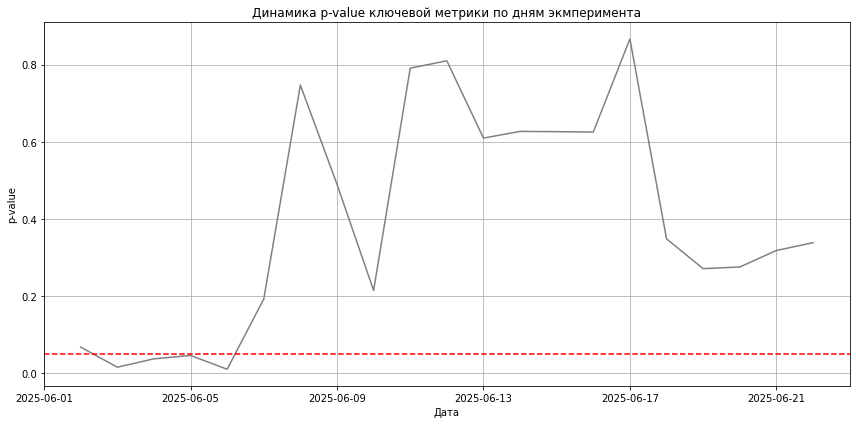

In [62]:
# Строим график чтобы визуализировать накопленную динамику p-value ключевой метрики по дням
# Задаем размер графика
plt.figure(figsize=(12, 6))

# Строим график
plt.plot(results_df['date'],results_df['p_value'],color='gray')

# Добавим линию уровня значимости
plt.axhline(y=0.05, linestyle='--', label='alpha = 0.05',color='red')

# Добавляем заголовок и подписи осей
plt.title('Динамика p-value ключевой метрики по дням экмперимента')
plt.xlabel('Дата')
plt.ylabel('p-value')

# Добавляем сетку
plt.grid(True)
plt.tight_layout()

# Выводим график
plt.show()

p-value был ниже уровня значимости только в течении первой недели, а затем оставался высоким до конца эксперимента.

#### Промежуточный вывод
В ходе анализа были рассмотрены ключевая метрика, барьерная метрика и две вспомогательные метрики. Для каждой метрики были сравнены значения в контрольной и тестовой группах, рассчитаны абсолютные и относительные изменения, а также проверена статистическая значимость различий.

**Ключевая метрика: средняя сумма всех депозитов на одного пользователя**

В тестовой группе средняя сумма депозитов на одного пользователя увеличилась по сравнению с контрольной:
* контрольная группа: 90.24
* тестовая группа: 92.46
* абсолютное изменение: +2.22
* относительное изменение: +2.46%

Однако статистический тест не подтвердил значимость различий (p-value = 0.338).

Таким образом, наблюдаемое увеличение ключевой метрики является небольшим и не позволяет сделать вывод о том, что изменение в тестовой группе действительно привело к росту средней суммы депозитов на пользователя.


**Барьерная метрика: конверсия из регистрации в первый депозит**

В тестовой группе наблюдается небольшое снижение конверсии:
* контрольная группа: 71.54%
* тестовая группа: 70.04%
* абсолютное изменение: −2.11 п.п.
* относительное изменение: −2.11%

Различия статистически незначимы (p-value = 0.121).

Следовательно, тестовое изменение не оказало подтверждённого влияния на вероятность совершения первого депозита после регистрации.

**Вспомогательная метрика №1: конверсия из первого депозита во второй**

Для данной метрики наблюдается наиболее выраженный положительный эффект:
* контрольная группа: 20.26%
* тестовая группа: 32.61%
* абсолютное изменение: +12.35 п.п.
* относительное изменение: +60.95%

Различия статистически значимы: (p-value = 1.9355885675373928e-28).

Это говорит о том, что тестовая версия значительно увеличила вероятность перехода пользователей от первого депозита ко второму.

**Вспомогательная метрика №2: средняя сумма депозитов среди пользователей, совершивших хотя бы один депозит**

В тестовой группе также наблюдается рост:
* контрольная группа: 135.50
* тестовая группа: 141.40
* абсолютное изменение: +5.90
* относительное изменение: +4.35%

Различия статистически значимы (p-value = 0.040).

Следовательно, среди пользователей, которые уже совершили депозит, тестовая группа показывает статистически значимое увеличение средней суммы депозитов.


**Анализ динамики ключевой метрики во время эксперимента**

По графику накопленной динамики ключевой метрики видно, что в начале эксперимента значения в тестовой и контрольной группах двигались достаточно близко и существенных различий между группами не наблюдалось.

Ближе к концу эксперимента наблюдается расхождение: тестовая группа показывает более высокий рост средней суммы депозитов на пользователя по сравнению с контрольной группой. Однако итоговый статистический тест не подтвердил значимость различий (p-value = 0.338), поэтому данный рост нельзя считать доказанным эффектом.


**Анализ стабильности p-value**

По графику динамики p-value видно, что значение статистической значимости сильно менялось в течение эксперимента.

В первые дни эксперимента p-value кратковременно опускался ниже уровня значимости 0.05, однако далее увеличился и большую часть периода находился значительно выше порогового значения.

К концу эксперимента p-value остаётся выше уровня значимости, что говорит об отсутствии стабильного статистически подтверждённого эффекта по ключевой метрике.

---

### 4. Анализ изменений суммы депозитов на платящего пользователя

Новая фича могла повлиять на поведение пользователей.
- Пользователи, которые раньше вносили небольшие суммы, могли стать более осторожными, сократить свои вложения или совсем перестать платить. Это отразится в снижении 25-го перцентиля суммы депозитов в тестовой группе.
- Пользователи, которые склонны к более крупным инвестициям, могли сильнее вовлечься в продукт и начать вносить больше средств. Это отразится в росте 75-го перцентиля.

Используя бутстрап, сравните разницы перцентилей (25, 50, 75) суммы всех депозитов на платящего пользователя в контрольной и тестовой группах:
- Постройте доверительные интервалы для разницы между группами для каждого перцентиля.
- Интерпретируйте изменения в контексте сформулированной выше гипотезы.
- Визуализируйте результат бутстрап-теста. 

<details>
<summary>Подсказка</summary>

В уроках вы использовали бутстрап, чтобы сравнивать средние значения двух групп. Вы визуализировали распределение разностей, рассчитывали доверительный интервал и делали выводы об эффекте изменений. В проекте вместо средних проанализируйте разницу значений 25, 50 и 75 перцентилей в тестовой и контрольной группах А/В-эксперимента.

Для этого постройте 95%-й доверительный интервал. Можете использовать пример ниже:


```python
# Пример бутстрап-теста
import numpy as np

# Фиксируем сид для воспроизводимости
np.random.seed(341)

# Для примера генерируем экспоненциальные данные: контроль и тест по 1000 наблюдений 
# со средними значениями 2.2 и 1.7
control = np.random.exponential(scale=2.2, size=1000)
test = np.random.exponential(scale=1.7, size=1000)

n_iterations = 1000
boot_diffs = []

# Бутстрап-разница 95-х перцентилей между тестовой и контрольной группами
for i in range(n_iterations):
    boot_control = np.random.choice(control, size=len(control), replace=True)
    boot_test = np.random.choice(test, size=len(test), replace=True)

    # Для расчёта 95 перцентиля используем .percentile() из библиотеки numpy 
    control_95p = np.percentile(boot_control, 95)
    test_95p = np.percentile(boot_test, 95)

    # Находим разницу между значениями тестовой и контрольной групп
    boot_diffs.append(test_95p - control_95p)

# Создаём массив разниц между 95-ми перцентилями тестовой и контрольной групп
boot_diffs = np.array(boot_diffs)

# Доверительный интервал разницы между 95-ми перцентилями (перцентильный метод)
diff_ci = np.percentile(boot_diffs, [2.5, 97.5])

# Вывод доверительного интервала
print(f"95-й перцентиль контрольной группы: {np.percentile(control, 95):.2f}")
print(f"95-й перцентиль тестовой группы: {np.percentile(test, 95):.2f}")
print(f"95%-й доверительный интервал разности 95-х перцентилей [{diff_ci[0]:.2f}, {diff_ci[1]:.2f}]")

```

</details>


In [63]:
# Фиксируем сид для воспроизводимости
np.random.seed(341)

# Создаем 2 выборки
# Будем использовать созданный ранее датафрейм user_amount_2, в котором хранятся данные только о платящих пользователях
control = user_amount_2[user_amount_2['group'] == 'control']['amount']
test = user_amount_2[user_amount_2['group'] == 'test']['amount']

# Задаём количество итераций 
n_iterations = 1000

In [64]:
# Создаем функцию для расчета доверительного интервала разности перцентилей с помощью бутстрапа
def bootstrap_percentile(control, test, percentile, n_iterations=1000):
    # Создаем пустой список для хранения разностей перцентилей
    boot_diffs = []
    
    # Выполняем бутстрап
    for i in range(n_iterations):
        # Формируем бутстрап-выборки для контрольной и тестовой групп
        boot_control = np.random.choice(control, size=len(control), replace=True)
        boot_test = np.random.choice(test, size=len(test), replace=True)
        # Рассчитываем заданный перцентиль для каждой бутстрап-выборки
        control_p = np.percentile(boot_control, percentile)
        test_p = np.percentile(boot_test, percentile)
        # Сохраняем разность перцентилей между тестовой и контрольной группами
        boot_diffs.append(test_p - control_p)
    
    # Преобразуем список разностей в массив NumPy
    boot_diffs = np.array(boot_diffs)
    
    # Рассчитываем 95%-й доверительный интервал перцентильным методом
    ci = np.percentile(boot_diffs, [2.5, 97.5])
    
    # Выводим значения перцентилей и доверительный интервал
    print(f'{percentile}-й перцентиль контрольной группы: {np.percentile(control, percentile):.2f}')
    print(f'{percentile}-й перцентиль тестовой группы: {np.percentile(test, percentile):.2f}')
    print(f'95%-й доверительный интервал: [{ci[0]:.2f}, {ci[1]:.2f}]\n')
    
    # Возвращаем распределение разностей и доверительный интервал
    return boot_diffs, ci

# Рассчитываем доверительные интервалы для 25-го, 50-го и 75-го перцентилей
boot25, ci25 = bootstrap_percentile(control, test, 25)
boot50, ci50 = bootstrap_percentile(control, test, 50)
boot75, ci75 = bootstrap_percentile(control, test, 75)

25-й перцентиль контрольной группы: 95.00
25-й перцентиль тестовой группы: 48.00
95%-й доверительный интервал: [-50.00, -44.00]

50-й перцентиль контрольной группы: 118.00
50-й перцентиль тестовой группы: 94.00
95%-й доверительный интервал: [-27.00, -19.00]

75-й перцентиль контрольной группы: 159.00
75-й перцентиль тестовой группы: 179.50
95%-й доверительный интервал: [11.00, 30.00]



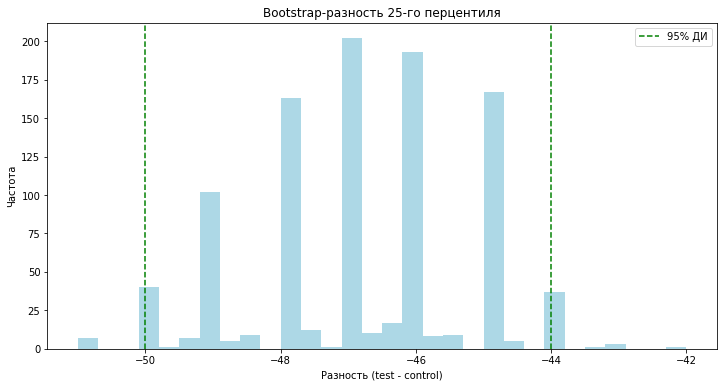

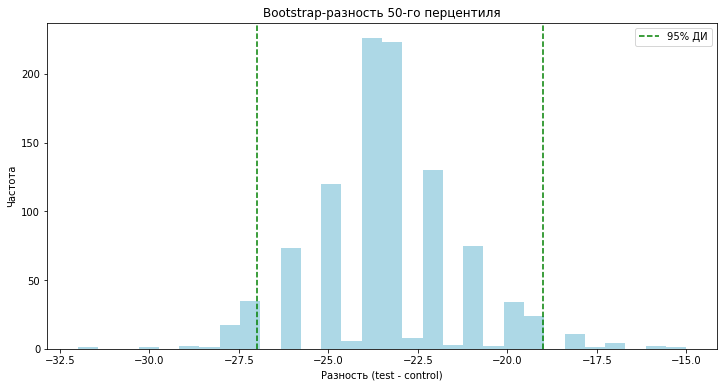

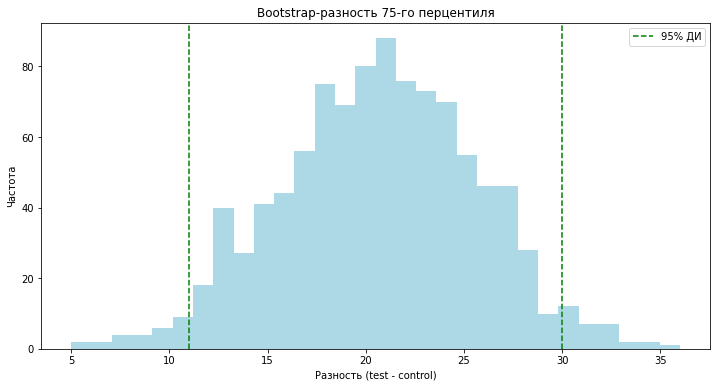

In [65]:
# Визуализируем результаты бутстрапа
# Данные для трех графиков
boot_data = [boot25, boot50, boot75]

# Список оверительных интервалов
ci_data = [ci25, ci50, ci75]

# Список перцентилей
percentiles = [25, 50, 75]

# Создаем цикл построения графиков
for boot, ci, p in zip(boot_data, ci_data, percentiles):

    # Задаем размер графика
    plt.figure(figsize=(12, 6))

    # Строим гистограмму bootstrap-распределения
    plt.hist(boot, bins=30, color='lightblue')

    # Добавляем нижнюю границу 95% доверительного интервала
    plt.axvline(ci[0], color='green', linestyle='--', label='95% ДИ')
    # Добавляем верхнюю границу 95% доверительного интервала
    plt.axvline(ci[1], color='green', linestyle='--')

    # Добавляем заголово и подписи осей
    plt.title(f'Bootstrap-разность {p}-го перцентиля')
    plt.xlabel('Разность (test - control)')
    plt.ylabel('Частота')

    # Добавляем легенду
    plt.legend()

    # Отображаем график
    plt.show()

#### Промежуточный вывод

По результатам bootstrap-анализов можно сделать вывод, что гипотеза о том, что небольшие вкладчики могли стать более осторожными, а крупные - увеличить свои вложения, в целом подтверждается.

**Анализ 25-го перцентиля**

В контрольной группе 25-й перцентиль суммы депозитов составил 95, тогда как в тестовой группе он снизился до 48. Разница между группами составила -47. 95%-й доверительный интервал для разницы находится в диапазоне от -50 до -44.

Так как весь доверительный интервал находится ниже нуля, снижение является статистически значимым. Это означает, что пользователи с небольшими депозитами после появления новой фичи стали вносить существенно меньшие суммы. Новая фича могла негативно повлиять на пользователей с небольшими суммами вложений. Они стали осторожнее, сократили размер депозитов или часть пользователей могла отказаться от дальнейших вложений.

**Анализ 50-го перцентиля**

Медианное значение суммы депозитов также снизилось. Значение контрольной группы равно 118, тестовой - 94. Разница составляет -24. 95%-й доверительный интервал находится в диапазоне от -27 до -19.

Интервал полностью находится ниже нуля, поэтому снижение медианного депозита также является статистически значимым. Изменение затронуло не только пользователей с минимальными депозитами, но и типичного пользователя: после внедрения фичи средний уровень вложений среди большинства пользователей снизился.

**Анализ 75-го перцентиля**

Для пользователей с более высокими суммами вложений наблюдается обратная тенденция:
* контрольная группа: 159
* тестовая группа: 179.5
* разница: +20.5
* 95%-й доверительный интервал находится в диапазоне от 11 до 29.75.

Так как весь доверительный интервал находится выше нуля, рост является статистически значимым.Пользователи, которые ранее были склонны к более крупным инвестициям, действительно могли сильнее вовлечься в продукт и увеличить размер своих депозитов после появления новой фичи.

---

# Выводы

Проведённый анализ показал, что новая фича не привела к статистически значимому росту ключевой метрики - средней суммы депозитов на пользователя (92,46 в тестовой группе против 90,24 в контрольной, p-value = 0,338). Также не было выявлено значимого влияния на барьерную метрику - конверсию из регистрации в первый депозит. Таким образом, основная гипотеза о прямом увеличении общего объёма депозитов на пользователя не подтвердилась.

При этом изменение оказало положительное влияние на дальнейшее поведение уже активных пользователей. Наиболее выраженный эффект наблюдается на этапе повторного взаимодействия с продуктом: конверсия из первого депозита во второй выросла с 20,26% до 32,61% (+60,95%, статистически значимо), а средняя сумма депозитов среди пользователей, совершивших хотя бы один депозит, увеличилась на 4,35%. Это говорит о том, что фича помогает повышать вовлечённость и удержание пользователей после первого финансового действия, но не влияет на привлечение новых вкладчиков.

Дополнительный анализ показал, что эффект различается в зависимости от уровня риска приобретаемых активов. Наибольший положительный результат наблюдается среди пользователей с активами высокого риска: вероятность открытия второго депозита выросла с 27,66% до 46,00%. Также значимый рост наблюдается для пользователей с активами низкого риска (с 49,82% до 57,46%). Для пользователей со средним уровнем риска статистически подтверждённого эффекта выявлено не было.

Анализ распределения депозитов показал, что после внедрения фичи пользователи с небольшими и средними суммами вложений стали вносить меньше: 25-й перцентиль снизился с 95 до 48, 50-й - со 118 до 94 (различия статистически значимы). Одновременно пользователи с крупными вложениями увеличили суммы депозитов: 75-й перцентиль вырос со 159 до 179,5. Это может свидетельствовать о перераспределении эффекта: фича усиливает вовлечённость наиболее ценных пользователей, но потенциально снижает активность части пользователей с меньшим объёмом вложений.

Таким образом, гипотеза подтвердилась частично: новая фича не увеличила общий объём депозитов на пользователя, но улучшила повторную активность и вовлечённость пользователей, уже начавших инвестировать. 

### Практические рекомендации

1. Не запускать фичу на всю аудиторию. Несмотря на положительное влияние на повторную активность пользователей, ключевая метрика эксперимента не улучшилась статистически значимо, поэтому оснований для полного внедрения пока недостаточно.

2. Провести доработку фичи с учетом уровня риска активов. Анализ показал, что наибольшую пользу изменения приносят пользователям с высоким и низким уровнем риска активов, тогда как для сегмента со средним уровнем риска эффект отсутствует. Имеет смысл адаптировать сценарии взаимодействия для разных категорий пользователей.

3. Доработать этап онбординга. Хотя снижение конверсии в первый депозит не оказалось статистически значимым, анализ воронки показал ухудшение прохождения онбординга. Стоит дополнительно исследовать, какие элементы новой фичи усложняют первые шаги пользователя, и протестировать более простые варианты интерфейса или подачи информации.

Если запустить фичу сейчас, это может понести следующие риски:

* Снижение активности пользователей с небольшими вложениями. Bootstrap-анализ показал статистически значимое снижение депозитов у пользователей нижней и средней частей распределения. Если эта тенденция сохранится, продукт может потерять часть массовой аудитории.

* Фича усиливает вовлечённость преимущественно активных и более крупных инвесторов, но практически не влияет на остальных пользователей. При полном запуске это может привести к росту различий между сегментами аудитории.

* Отсутствие подтверждённого роста основной бизнес-метрики. Несмотря на улучшение вспомогательных показателей, ключевая метрика не изменилась статистически значимо. Поэтому существует риск внедрить изменение, которое усложнит пользовательский опыт, но не принесёт ожидаемого роста бизнеса.

Возможно, эффект проявляется только в долгосрочной перспективе. Поскольку к концу эксперимента наблюдалась тенденция к росту ключевой метрики, нельзя исключать, что текущей длительности теста оказалось недостаточно для фиксации полного эффекта. Перед окончательным решением стоит оценить результаты на более длительном периоде.